<h2>Data Analytics - World Energy Consumption (1900-2022)</h2>

<h4><b>Short description:</b></h4>

World Energy Consumption. A comprehensive longitudinal dataset covering global and country level energy production, consumption and electricity generation across all major energy sources from 1900 to 2022.

<h4><b>Data source (url):</b></h4>

https://www.kaggle.com/datasets/pralabhpoudel/world-energy-consumption/data

<h4><b>Data format:</b></h4>

Single CSV file. Rows represent one country for one year. The file contains 22,012 rows and 129 columns.

<h4><b>Data description, features and limitations:</b></h4>

The dataset covers 306 unique entities. Key features include:

- **Energy consumption** (TWh) broken down by source: coal, oil, gas, solar, wind, hydro, nuclear, biofuel and other renewables
- **Energy production** (TWh) for fossil fuels
- **Electricity generation** (TWh) by source
- **Share metrics** each source's percentage share of total energy and electricity

**Limitations:**
- Coverage is sparse before 1965. The "1900–2022" range mostly reflects fossil fuel data. renewables data (solar, wind) only becomes reliable from the 1980s–1990s onward.
- Many columns have 80%+ missing values, particularly change percentage columns and per capita breakdowns for smaller nations.
- Regional aggregates are included in the raw data alongside individual countries, so filtering is required to avoid double counting in country level analyses.

<h3><b>Code: Importing modules, custom functions and loading the data</b></h3>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# consistent plot style throughout the notebook
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 5)

# load the raw dataset
df_raw = pd.read_csv('World Energy Consumption.csv')

print(f'Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Countries/entities: {df_raw["country"].nunique()}')
print(f'Year range: {df_raw["year"].min()} – {df_raw["year"].max()}')
df_raw.head(5)

Raw dataset: 22,012 rows × 129 columns
Countries/entities: 306
Year range: 1900 – 2022


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


<h3><b>Code: Data clean-up procedure</b></h3>

The raw dataset mixes individual countries with regional and income group aggregates (e.g. "Africa", "G20", "High income countries"). Including both would cause double counting in any global comparison, so I split them into two separate DataFrames:

- **df_countries** - rows where iso_code is present
- **df_world** - a single time series using the 'World' aggregate for global trend analysis

In [2]:
# iso_code is only present for actual sovereign nations
# aggregates have NaN iso_code - I use this as the filter.
df_countries = df_raw[df_raw['iso_code'].notna()].copy()
df_world = df_raw[df_raw['country'] == 'World'].copy().sort_values('year')

print(f'Country rows: {len(df_countries):,}')
print(f'World aggregate rows: {len(df_world)}')

Country rows: 16,512
World aggregate rows: 123


In [3]:
# Drop columns with >80% missing values
# I use AI to identify columns with too much missing data
# These columns are too sparse to be analytically meaningful across the full dataset.
missing_pct = df_countries.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.80].index.tolist()

print(f'Dropping {len(cols_to_drop)} columns with >80% missing values:')
print(cols_to_drop)

df_countries = df_countries.drop(columns=cols_to_drop)
df_world = df_world.drop(columns=[c for c in cols_to_drop if c in df_world.columns])

print(f'\nDataset after drop: {df_countries.shape[1]} columns remaining')

Dropping 17 columns with >80% missing values:
['biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_share_energy', 'electricity_share_energy', 'nuclear_cons_change_pct', 'nuclear_cons_change_twh', 'nuclear_consumption', 'nuclear_energy_per_capita', 'nuclear_share_energy', 'other_renewables_cons_change_pct', 'other_renewables_share_energy', 'solar_cons_change_pct', 'solar_share_energy', 'wind_cons_change_pct', 'wind_share_energy']

Dataset after drop: 112 columns remaining


In [4]:
# Define column groups
# Rather than working with all 100+ columns at once I group them by theme.

FOSSIL_COLS   = ['coal_consumption', 'oil_consumption', 'gas_consumption']
RENEW_COLS    = ['solar_consumption', 'wind_consumption', 'hydro_consumption', 'other_renewable_consumption']
NUCLEAR_COL   = ['nuclear_consumption']
SOURCE_COLS   = FOSSIL_COLS + RENEW_COLS + NUCLEAR_COL
SHARE_COLS    = ['fossil_share_energy', 'renewables_share_energy', 'low_carbon_share_energy']
ELEC_COLS     = ['coal_electricity', 'oil_electricity', 'gas_electricity',
                 'solar_electricity', 'wind_electricity', 'hydro_electricity', 'nuclear_electricity']


<h3><b>Code: Data analysis</b></h3>

The analysis is structured into four sections:
1. **Global energy trends (1900–2022)** - how the world's energy mix has evolved over 120 years
2. **Country comparisons** - who consumes the most and who leads on renewables
3. **Energy source correlations** - how different sources relate to each other and to GDP/population
4. **The renewable transition** - solar and wind growth since 1990

---

### Section 1 - Global energy mix over time (World aggregate)

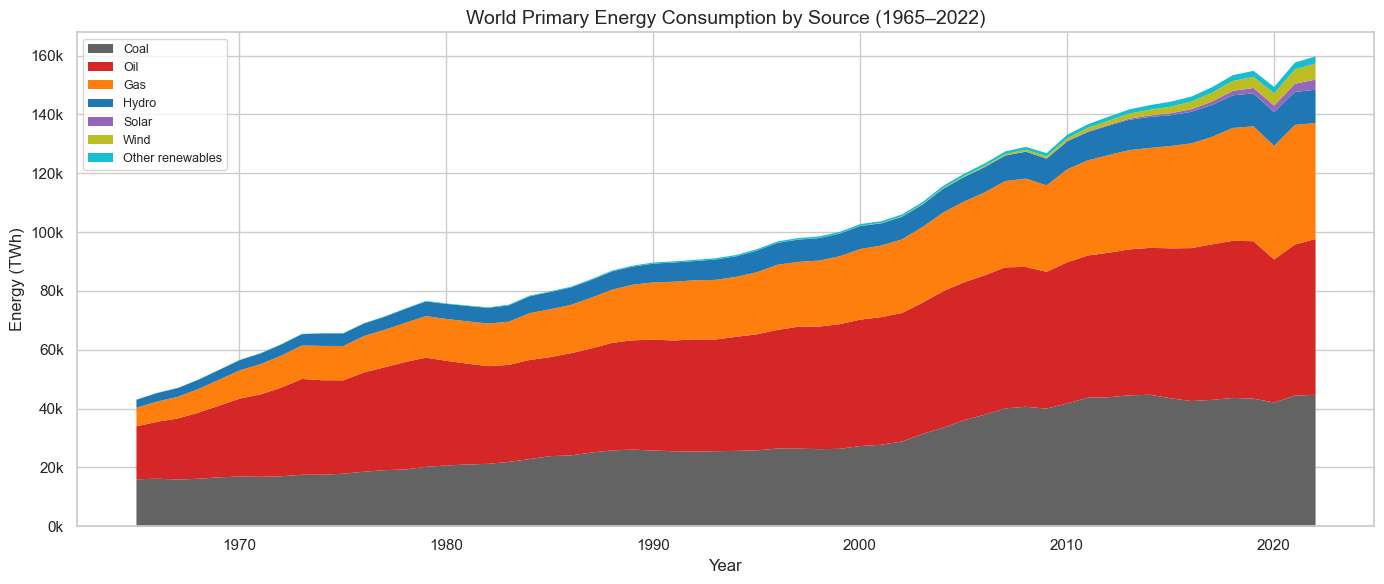

In [5]:
# I use the 'World' aggregate row (not summing countries) to avoid gaps from
# I used AI to get a idea about which plot type is most suitable for showing the global energy consumption trends by source over time.

# Filter SOURCE_COLS to only columns that survived the >80% missing-data drop
available_source_cols = [c for c in SOURCE_COLS if c in df_world.columns]
world_sources = df_world.dropna(subset=available_source_cols, how='all').set_index('year')

source_labels = {
    'coal_consumption':            'Coal',
    'oil_consumption':             'Oil',
    'gas_consumption':             'Gas',
    'hydro_consumption':           'Hydro',
    'nuclear_consumption':         'Nuclear',
    'solar_consumption':           'Solar',
    'wind_consumption':            'Wind',
    'other_renewable_consumption': 'Other renewables'
}

plot_data = world_sources[[c for c in source_labels if c in world_sources.columns]].fillna(0)
plot_data.columns = [source_labels[c] for c in plot_data.columns]

colors = ['#636363','#d62728','#ff7f0e','#1f77b4','#9467bd','#bcbd22','#17becf','#2ca02c']

fig, ax = plt.subplots(figsize=(14, 6))
plot_data.plot.area(ax=ax, color=colors[:len(plot_data.columns)], linewidth=0)
ax.set_title('World Primary Energy Consumption by Source (1965–2022)', fontsize=14)
ax.set_ylabel('Energy (TWh)')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Coal, oil and gas have dominated global energy since records began.
# The combined fossil fuel area still towers over renewables even in 2022.
# However, the small but rapidly growing sliver at the top it's solar and wind consumption. 

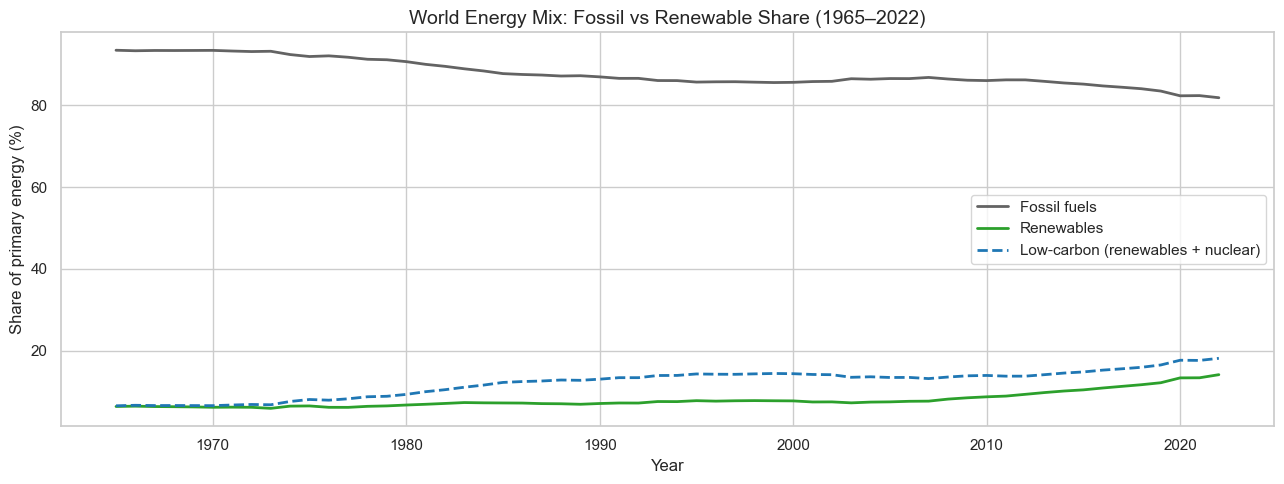

In [6]:
# Fossil share vs renewable share over time
# A picture of the energy transition. What percentage of world energy
# comes from fossil fuels vs renewables vs nuclear. 

share_world = df_world.dropna(subset=['fossil_share_energy', 'renewables_share_energy']).set_index('year')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(share_world.index, share_world['fossil_share_energy'],    label='Fossil fuels', color='#636363', linewidth=2)
ax.plot(share_world.index, share_world['renewables_share_energy'], label='Renewables',   color='#2ca02c', linewidth=2)
ax.plot(share_world.index, share_world['low_carbon_share_energy'], label='Low-carbon (renewables + nuclear)', color='#1f77b4', linewidth=2, linestyle='--')
ax.set_title('World Energy Mix: Fossil vs Renewable Share (1965–2022)', fontsize=14)
ax.set_ylabel('Share of primary energy (%)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

# During these years the fossil fuel share has barely declined
# it remains above 80% as of 2022. Renewables have grown but also total enegry consumption has increased also. 
# The 'low-carbon' line (renewables + nuclear) shows that nuclear has
# contributed more to decarbonisation than wind and solar combined.

___

### Section 2 - Country comparisons

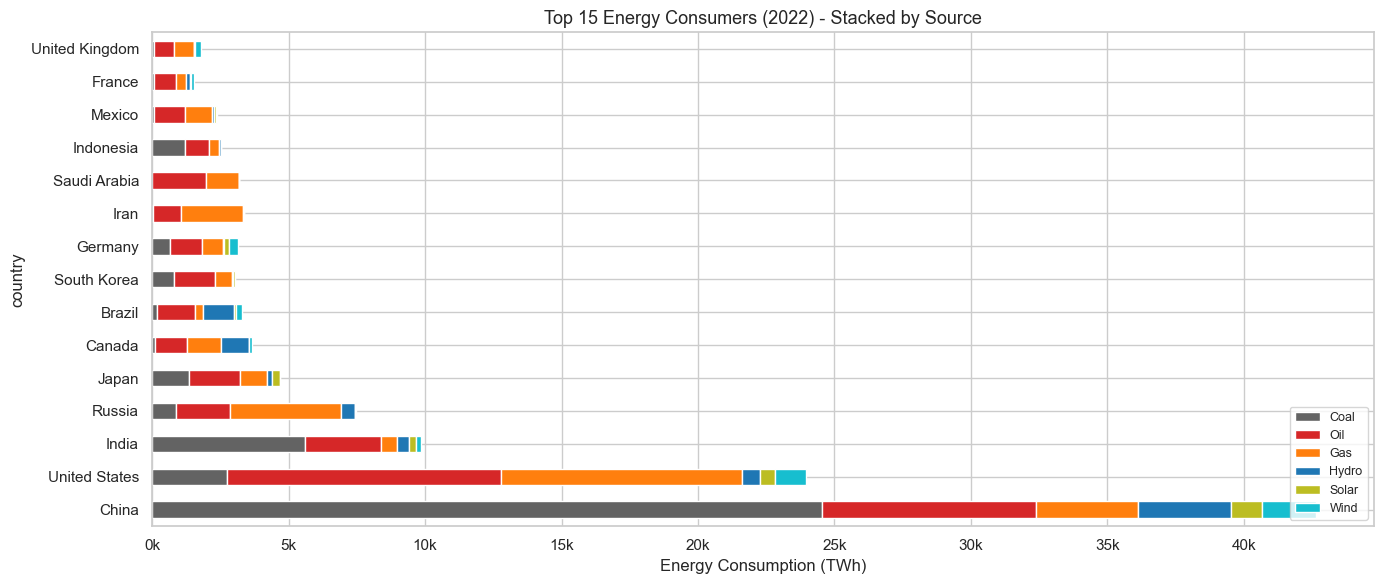

In [7]:
# Top 15 energy consuming countries
# Using the most recent year with wide coverage.
# I stack each country's bar by energy source to show mix alongside total volume.

latest = df_countries[df_countries['year'] == 2022].dropna(subset=['primary_energy_consumption'])
top15 = latest.nlargest(15, 'primary_energy_consumption').set_index('country')

bar_sources = ['coal_consumption','oil_consumption','gas_consumption',
               'hydro_consumption','nuclear_consumption','solar_consumption','wind_consumption']
bar_labels  = ['Coal','Oil','Gas','Hydro','Nuclear','Solar','Wind']
bar_colors  = ['#636363','#d62728','#ff7f0e','#1f77b4','#9467bd','#bcbd22','#17becf']

# Filter to only columns that survived the >80% missing-data drop
df_meta = pd.DataFrame({'source': bar_sources, 'label': bar_labels, 'color': bar_colors})
df_meta = df_meta[df_meta['source'].isin(top15.columns)]
bar_sources = df_meta['source'].tolist()
bar_labels  = df_meta['label'].tolist()
bar_colors  = df_meta['color'].tolist()

bar_data = top15[list(bar_sources)].fillna(0)
bar_data.columns = list(bar_labels)

fig, ax = plt.subplots(figsize=(14, 6))
bar_data.plot(kind='barh', stacked=True, ax=ax, color=list(bar_colors))
ax.set_title('Top 15 Energy Consumers (2022) - Stacked by Source', fontsize=13)
ax.set_xlabel('Energy Consumption (TWh)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# China and the USA are in a league of their own. 
# China's dominance is driven almost entirely by coal. 
# The USA energy mix is more diverse (oil + gas heavy).
# India is third and also very coal dependent country.
# Canada and Brazil both show notably larger renewable (hydro) portions compared to others.

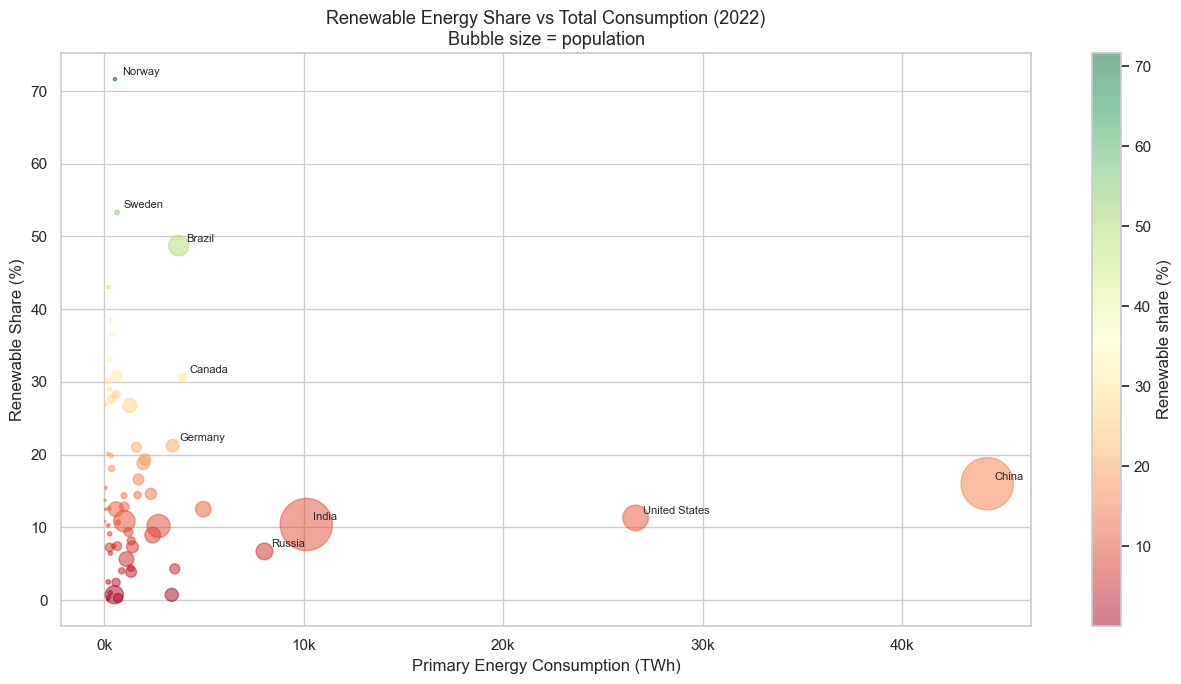

In [8]:
# Renewable share vs total energy consumption (bubble chart - 2022)

# This chart is fully generated by AI
# I asked AI to suggest a way to visualize the relationship between total energy consumption and 
# renewable share across countries, while also showing population size. 
# The bubble chart is a good way to capture all three dimensions in one view.
# I checked the code and I understand how it works. It filters to countries with data on all three dimensions, 
# then plots primary energy consumption on the x-axis, renewable share on the y-axis and scales 
# bubble size by population. It also annotates some key countries for clarity.
# Bubble size = population. Only countries with enough data shown.

bubble = latest.dropna(subset=['renewables_share_energy', 'primary_energy_consumption', 'population'])

fig, ax = plt.subplots(figsize=(13, 7))

scatter = ax.scatter(
    bubble['primary_energy_consumption'],
    bubble['renewables_share_energy'],
    s=bubble['population'] / 1e6,       # scale bubble by millions of people
    alpha=0.5,
    c=bubble['renewables_share_energy'],
    cmap='RdYlGn'
)

# annotate the most interesting outliers
highlight = ['China', 'United States', 'India', 'Norway', 'Brazil', 'Russia', 'Germany', 'Canada', 'Sweden']
for _, row in bubble[bubble['country'].isin(highlight)].iterrows():
    ax.annotate(row['country'],
                (row['primary_energy_consumption'], row['renewables_share_energy']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='Renewable share (%)')
ax.set_title('Renewable Energy Share vs Total Consumption (2022)\nBubble size = population', fontsize=13)
ax.set_xlabel('Primary Energy Consumption (TWh)')
ax.set_ylabel('Renewable Share (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

# High total consumption does not guarantee a high renewable share.
# the largest consumers (China, USA, India) all cluster at the low renewable end.
# Norway is a notable outlier. a high consumption country with >70% renewable share
# Sweden is also in 50-60% renewable share range 
# Brazil also stands out. 

C:\Users\savin\AppData\Local\Temp\ipykernel_10340\1609795291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_renew, x='country', y='renewables_share_energy',


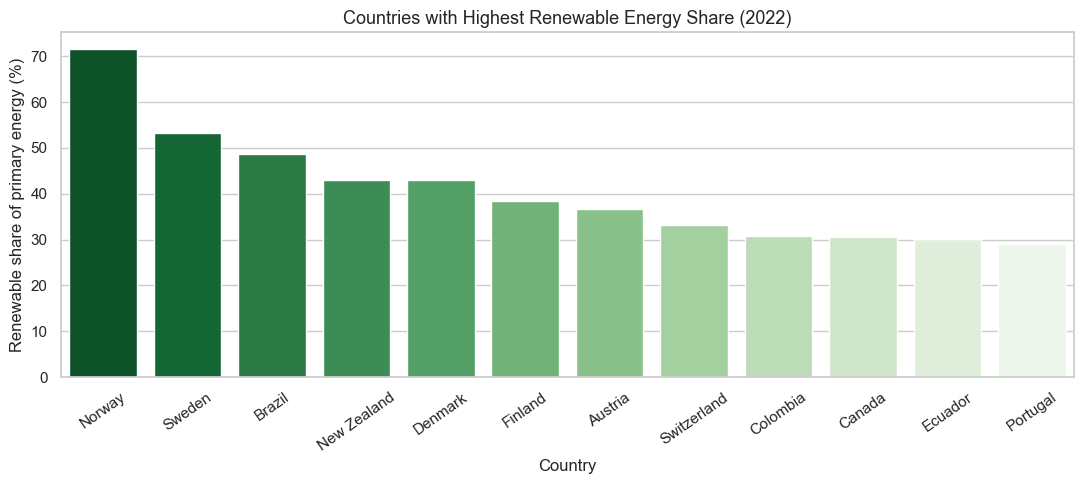

In [9]:
# Top 12 countries by renewable share (2022)

top_renew = latest.dropna(subset=['renewables_share_energy']).nlargest(12, 'renewables_share_energy')

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top_renew, x='country', y='renewables_share_energy',
            palette='Greens_r', ax=ax)
ax.set_title('Countries with Highest Renewable Energy Share (2022)', fontsize=13)
ax.set_xlabel('Country')
ax.set_ylabel('Renewable share of primary energy (%)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

# The top renewable countries are almost all small. Those are hydro rich nations.
# Norway (71%), Sweden (53%), New Zealand, Denmark, Finland.
# This pattern raises an important point. Hydro is geography dependent. 
# The renewablesfor large continental nations (China, USA, India) will have to use solar and wind instead.

___

### Section 3 - Correlation analysis

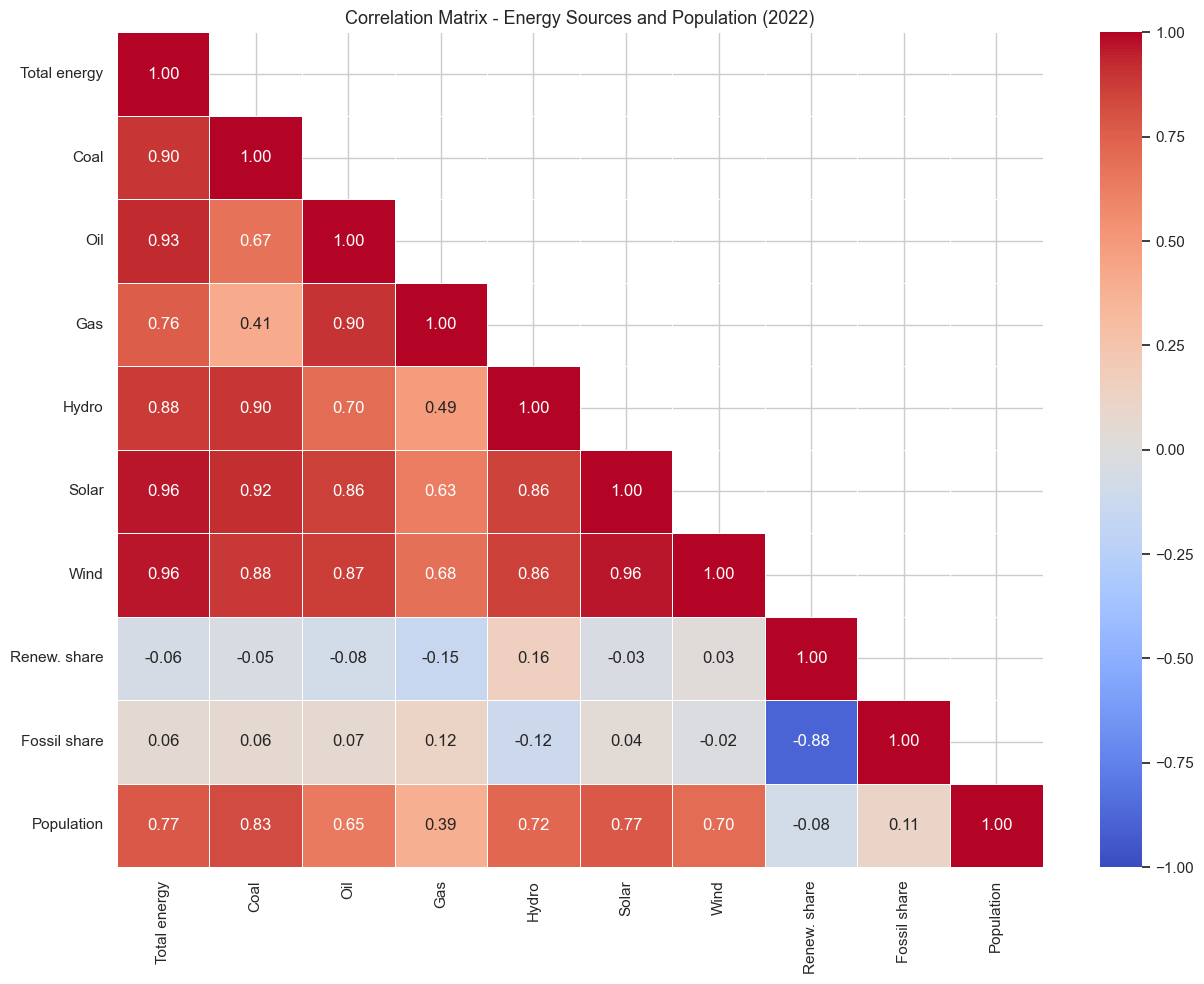

In [13]:
# Correlation heatmap: energy sources + population 
# I use 2022 country level data for this.

corr_cols = ['primary_energy_consumption', 'coal_consumption', 'oil_consumption',
             'gas_consumption', 'hydro_consumption',
             'solar_consumption', 'wind_consumption',
             'renewables_share_energy', 'fossil_share_energy', 'population']

corr_cols = [c for c in corr_cols if c in latest.columns]

corr_matrix = latest[corr_cols].corr()

# Shorter axis labels for readability
label_map = {
    'primary_energy_consumption': 'Total energy',
    'coal_consumption':           'Coal',
    'oil_consumption':            'Oil',
    'gas_consumption':            'Gas',
    'hydro_consumption':          'Hydro',
    'solar_consumption':          'Solar',
    'wind_consumption':           'Wind',
    'renewables_share_energy':    'Renew. share',
    'fossil_share_energy':        'Fossil share',
    'population':                 'Population',
}
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(13, 10))
# k=1 masks only the strict upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - Energy Sources and Population (2022)', fontsize=13)
plt.tight_layout()
plt.show()

# Key observations from the heatmap:
# - Population and total energy are strongly correlated (r ≈ 0.77). This means 
#   larger nations consume vastly more energy.
# - All fossil fuels correlate strongly with each other and with total consumption.
# - renewables share energy has a strong NEGATIVE correlation with fossil share energy (r ≈ -0.88).
# - solar and wind show low correlation with hydro.

___

### Section 4 - The renewable transition: solar and wind growth since 1990

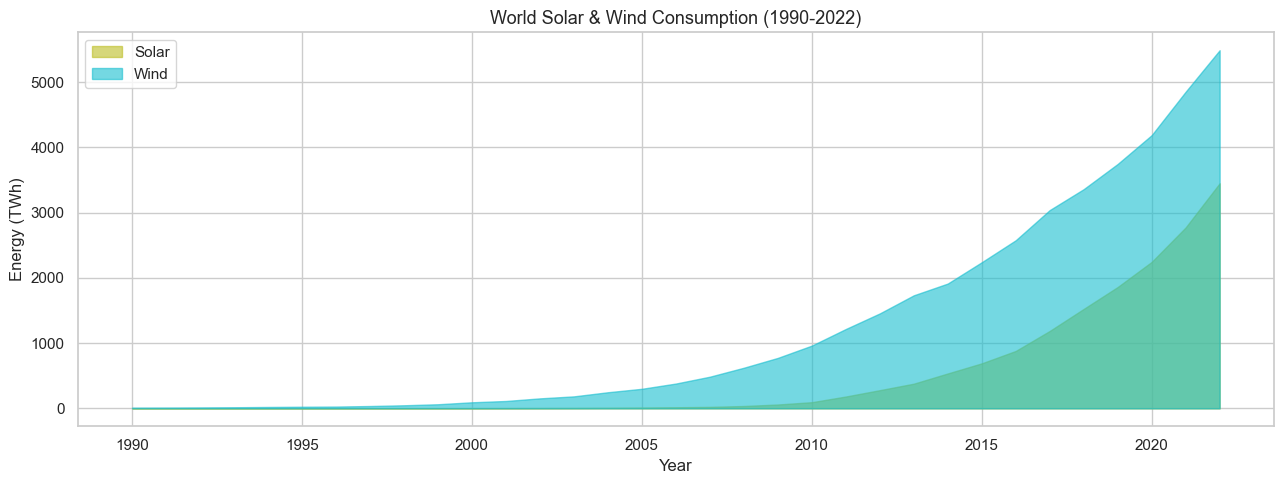

In [14]:
# Global solar & wind growth (World aggregate, 1990–2022)
# Solar and wind were essentially zero before 1990. This chart shows their
# growth. particularly solar after 2010.

sw_world = df_world[df_world['year'] >= 1990].dropna(subset=['solar_consumption','wind_consumption'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(sw_world['year'], sw_world['solar_consumption'], alpha=0.6,
                color='#bcbd22', label='Solar')
ax.fill_between(sw_world['year'], sw_world['wind_consumption'], alpha=0.6,
                color='#17becf', label='Wind')
ax.set_title('World Solar & Wind Consumption (1990-2022)', fontsize=13)
ax.set_ylabel('Energy (TWh)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

# By 2022, wind still outpaces solar but solar is catching up

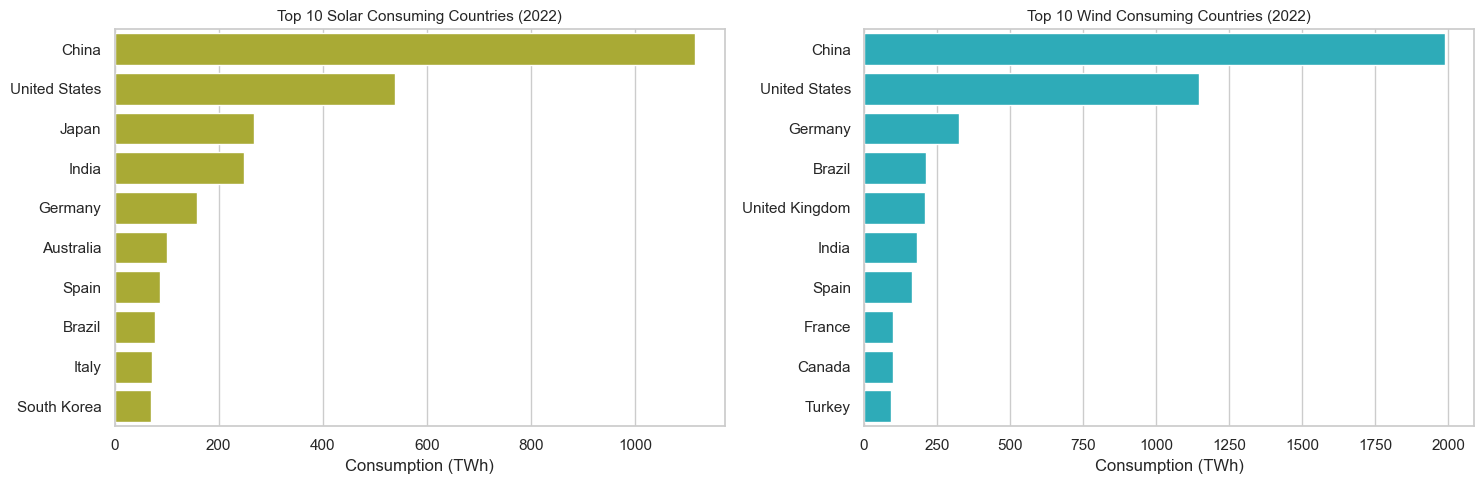

In [15]:
# Top solar and wind countries (2022) — side by side comparison
# I use AI to correctly code loop to create two side by side bar charts. 

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, title, color in zip(
    axes,
    ['solar_consumption', 'wind_consumption'],
    ['Top 10 Solar Consuming Countries (2022)', 'Top 10 Wind Consuming Countries (2022)'],
    ['#bcbd22', '#17becf']
):
    top = latest.dropna(subset=[col]).nlargest(10, col)
    sns.barplot(data=top, x=col, y='country', color=color, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Consumption (TWh)')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# China leads both solar and wind by a significant margin. 
# The USA is second in both categories.
# Interestingly, India appears in the top 10 for solar but not wind.
# reflecting its large scale solar programme in the Thar Desert and other regions. (google findings)
# Germany and Spain are the notable European countries. 

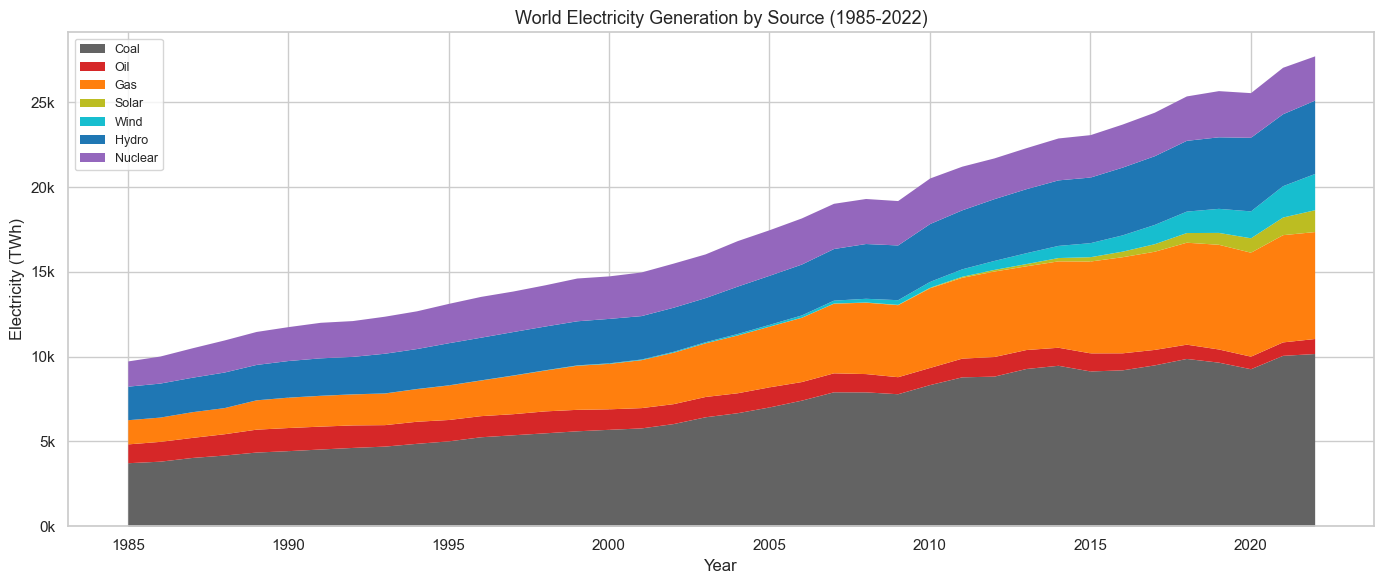

In [16]:
# Long-run trend: electricity generation mix (World, 1985–2022)
# Electricity generation is where the renewable transition is most visible,
# since solar/wind feed directly into grids.

elec_world = df_world[df_world['year'] >= 1985].dropna(subset=ELEC_COLS, how='all').set_index('year')

elec_plot = elec_world[ELEC_COLS].fillna(0)
elec_plot.columns = ['Coal','Oil','Gas','Solar','Wind','Hydro','Nuclear']

elec_colors = ['#636363','#d62728','#ff7f0e','#bcbd22','#17becf','#1f77b4','#9467bd']

fig, ax = plt.subplots(figsize=(14, 6))
elec_plot.plot.area(ax=ax, color=elec_colors, linewidth=0)
ax.set_title('World Electricity Generation by Source (1985-2022)', fontsize=13)
ax.set_ylabel('Electricity (TWh)')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# The electricity picture is more encouraging than the primary energy picture.
# Solar and wind are clearly visible and growing fast.
# Nuclear grew strongly.
# Coal has begun to flatten but gas has partially taken its place.
# Total electricity demand has roughly tripled since 1985.

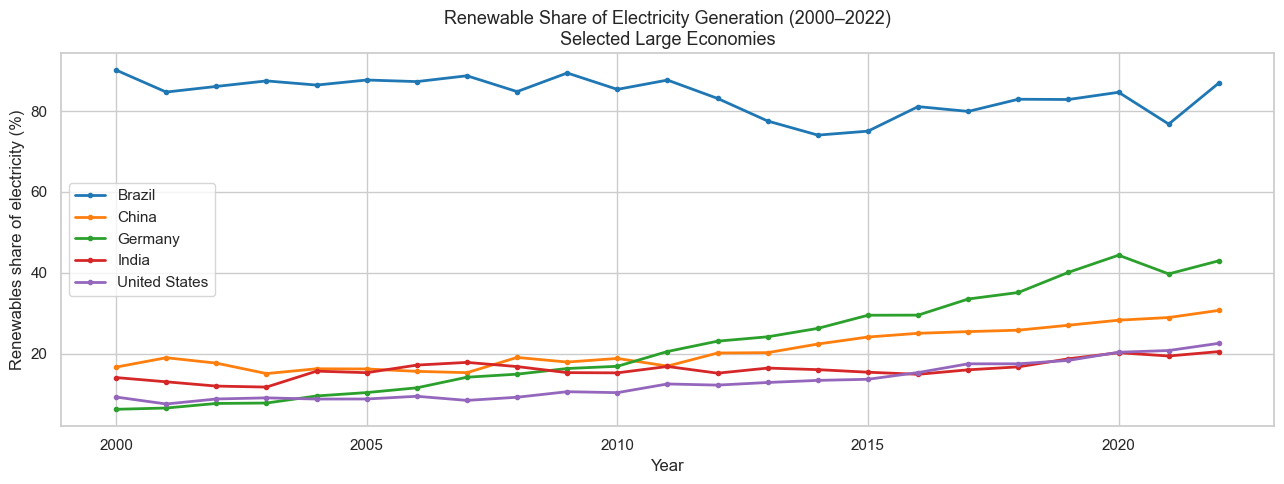

In [ ]:
# Renewable share of electricity: top 5 large selected economies over time

big5 = ['United States', 'China', 'India', 'Germany', 'Brazil']
big5_data = df_countries[
    (df_countries['country'].isin(big5)) &
    (df_countries['year'] >= 2000)
].dropna(subset=['renewables_share_elec'])

fig, ax = plt.subplots(figsize=(13, 5))
for country, group in big5_data.groupby('country'):
    ax.plot(group['year'], group['renewables_share_elec'], marker='o', markersize=3,
            linewidth=2, label=country)

ax.set_title('Renewable Share of Electricity Generation (2000–2022)\nSelected Large Economies', fontsize=13)
ax.set_ylabel('Renewables share of electricity (%)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

# Brazil has maintained a high renewable electricity share throughout (mostly hydro),
# but has not grown it significantly.
# Germany has seen the most dramatic increase from ~7% in 2000 to ~45% in 2022,
# China's share has grown from ~19% to ~30% but the
# absolute increase in coal generation has been even larger in the same period.
# India's share remains low but is rising primarily from solar expansion.

___
___

<h3><b>Results and summary:</b></h3>

1. **Fossil fuels remain dominant.** Despite decades of climate policy, fossil fuels still account for over 80% of global primary energy as of 2022. Total fossil consumption has grown even as the renewable share increases because overall energy demand keeps rising.

2. **Solar and wind are growing exponentially but from a small base.** They supply only ~5% of global primary energy in 2022 though their growth rate since 2010 is very good. The electricity sector is further along the transition than primary energy as a whole.

3. **The largest consumers are not using cleanest energy.** China, USA and India dominate total consumption and are heavily fossil fuel dependent. High renewable countries (Norway, Sweden, Denmark, Brazil) are smaller economies whose renewable advantage comes primarily from geography dependent hydro resources.

4. **Germany's electricity transition stands out.** Among large economies, Germany increased its renewable electricity share from ~7% in 2000 to ~45% in 2022. The most dramatic shift of any major economy in the dataset.

<h3><b>Ideas for further improvements:</b></h3>

- Combine with emissions data
- Per capita electricity generation